## Task

Your goal is to find out whether it is possible to reliably predict whether a website is a phishing site or not 
based on the 
easily obtainable information about the website. Based on the outcome, it may become possible to construct an 
automated system that warns users when they are about to visit a phishing website.

### Part 1: Decision tree

Your initial goal is to construct a small yet useful decision tree that predicts whether a website is a
phishing site or not.

The outcome should contain the following:
1. An image of the final decision tree.
2. Evaluation metrics for the decision tree.
3. Written instructions for an internet analyst to manually make the decision of whether the website
is likely to be a phishing site or not. The instructions must match one-to-one with your
decision tree, and be written in a way that is understandable to an engineer who is aware of the basics of internet technologies.

### Part 2: Random forest

As the ultimate goal is to build an automated system, you don't have to stick to a single, relatively simple decision tree.

Try to tweak the performance of the decision tree by replacing it with a random forest. You may also try to tune the 
hyperparameters of the random forest to improve the performance.

Be sure to include the validation results in your report.

> In real life, when you tune the hyperparameters based on the validation results, you should have yet another 
> data set that is not used for tuning the hyperparameters, but applied only once after the tuning of the 
> hyperparameters to obtain the final performance estimate of the tuned model.
> That is, there should be three sets: training, validation, and test sets. On this course, you may skip the need for the third set.

## CRISP-DM
This notebook follows the CRISP-DM process model

CRISP-DM phases:

1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.


## 1. Business understanding

Goal of this project is to build a machine learning models to detect whether a website is a **Phishing site** or a **Legitimate  site** using easily obtainable website characteristics.

A **Phishing site** is marked as **-1** and a **Legitimate site** as **1**.

## 2. Data understanding

## 2.x Importing the data
The dataset contains website characteristics extracted from webpages, including URL structure, domain registration details, security certificate (SSL) features and page source attributes. The features are all easily obtainable without executing any risky code on the target websites.


In [1]:
import itertools

from numpy.ma.extras import average
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# Data
features : DataFrame = phishing_websites.data.features
targets : DataFrame = phishing_websites.data.targets

# Metadata and variables info
metadata : DataFrame = phishing_websites.metadata
variables : DataFrame = phishing_websites.variables

# Dynamically extract target column name to prevent KeyError
target_col = targets.columns[0]

print(f"Dataset Shape: {features.shape[0]} samples, {features.shape[1]} features")
print(f"\nClass Distribution in '{target_col}' (1 = Legitimate, -1 = Phishing):")
print(targets[target_col].value_counts())

Dataset Shape: 11055 samples, 30 features

Class Distribution in 'result' (1 = Legitimate, -1 = Phishing):
result
 1    6157
-1    4898
Name: count, dtype: int64


# 2.x Features & Metadata


In [2]:
# Example of data
features.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1


In [3]:
# Metadata
metadata


{'uci_id': 327,
 'name': 'Phishing Websites',
 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites',
 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv',
 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.',
 'area': 'Computer Science',
 'tasks': ['Classification'],
 'characteristics': ['Tabular'],
 'num_instances': 11055,
 'num_features': 30,
 'feature_types': ['Integer'],
 'demographics': [],
 'target_col': ['result'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2012,
 'last_updated': 'Tue Mar 05 2024',
 'dataset_doi': '10.24432/C51W2X',
 'creators': ['Rami Mohammad', 'Lee McCluskey'],
 'intro_paper': {'ID': 396,
  'type': 'NATIVE',
  'title': 'An assessment of features related to phishing websites using an automated technique',
  'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey',
  'venue': 'International

### 2.6 Variables

The dataset should not have any missing variables.

In [4]:
# Variable information
variables

,name,role,type,demographic,description,units,missing_values
0,having_ip_address,Feature,Integer,None,None,None,no
1,url_length,Feature,Integer,None,None,None,no
2,shortining_service,Feature,Integer,None,None,None,no
3,having_at_symbol,Feature,Integer,None,None,None,no
4,double_slash_redirecting,Feature,Integer,None,None,None,no
5,prefix_suffix,Feature,Integer,None,None,None,no
6,having_sub_domain,Feature,Integer,None,None,None,no
7,sslfinal_state,Feature,Integer,None,None,None,no
8,domain_registration_length,Feature,Integer,None,None,None,no
9,favicon,Feature,Integer,None,None,None,no


### 2.7 Data Understanding: Summary

- The dataset contains 11 055 total website entries with 30 explanatory features as well as 1 target variable **Result**. This makes the total of 30 variables per entry.

- All 30 features are categorical taking values of **-1, 0 or 1**. These values indicate whether it's phishing, suspicious or legitimate.

### 2.8 Data Understanding: Conclusions

- Data standardization is not required as Decision Trees and Random Forests split variables based on threshold conditions.

## 3. Data Preparation


## 3.1 Separating training and testing data
- Feature standardization is omitted because Decision Trees and Random Forests evaluate individual feature split thresholds independently.
- 80/20 train-test holdout split is applied.

In [5]:
from sklearn.model_selection import train_test_split

# 3.1 Splitting data into training and testing sets
target_col = targets.columns[0]
y = targets[target_col]

# Hold-out validation split
features_train, features_test, target_train, target_test = train_test_split(
    features, 
    y, 
    test_size=0.25, 
    random_state=42, 
    stratify=y
)

# Confirm equal alignment and dataset split sizes
assert len(features_train) == len(target_train)
assert len(features_test) == len(target_test)

print("Data Preparation Completed:")
print(f"Training set size: {features_train.shape[0]} samples.")
print(f"Testing set size: {features_test.shape[0]} samples.")

Data Preparation Completed:
Training set size: 8291 samples.
Testing set size: 2764 samples.


### 3.2 Interpretation
Data did not have any missing values. It is now properly splitted for training and testing.

## 4. Modeling

### 4.1 Baseline model

Training model without tweaking depth or which feature to use.

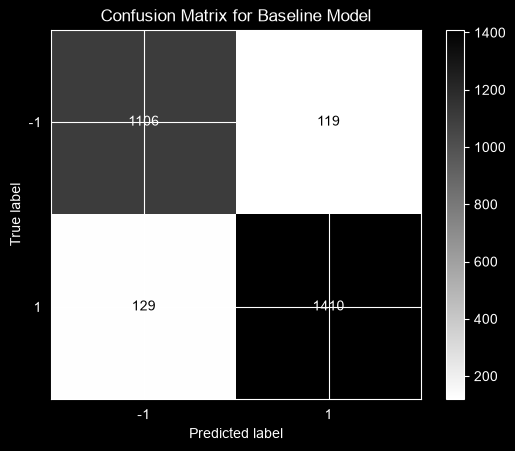

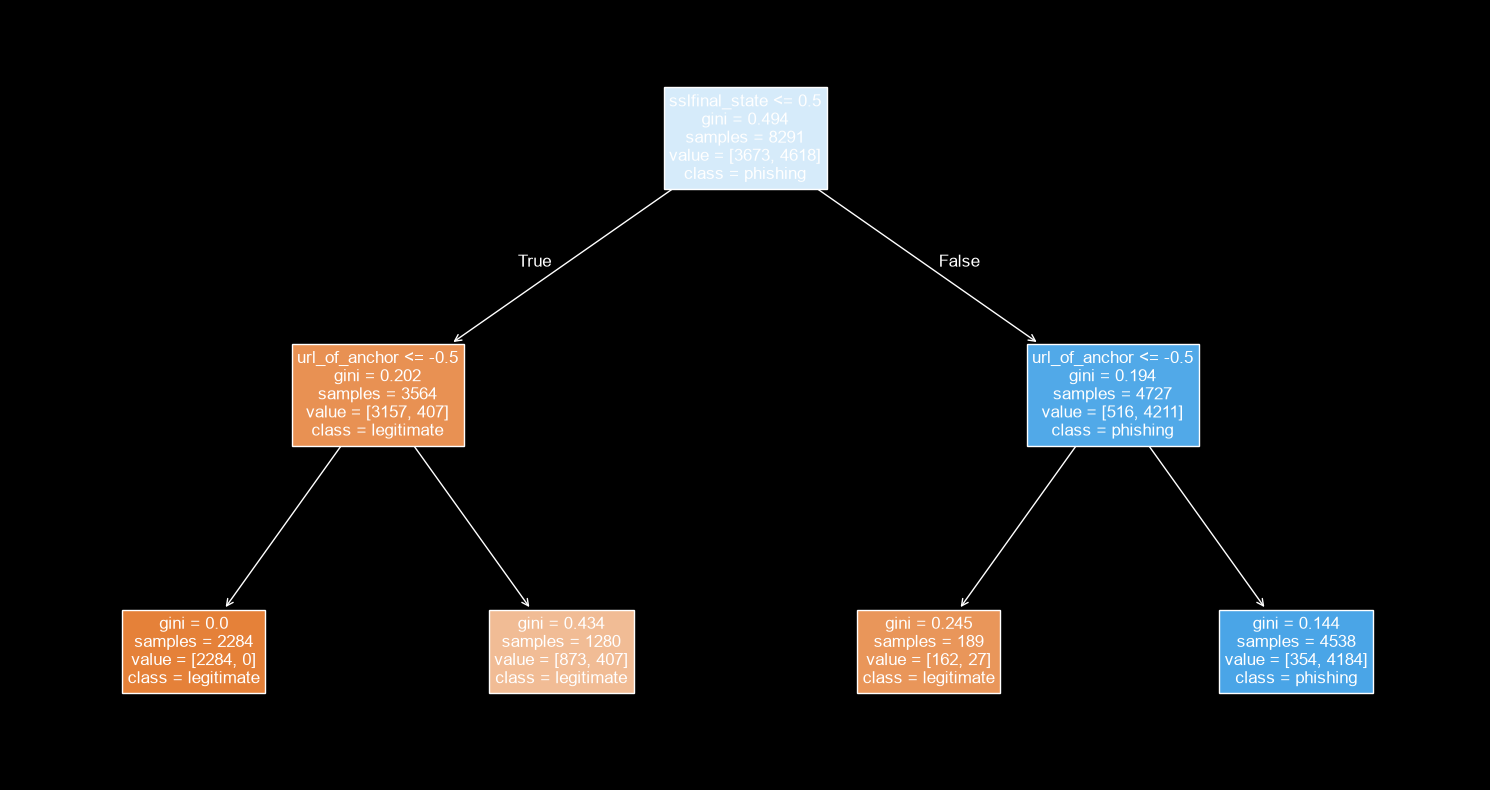

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

# train the model with training data
model = DecisionTreeClassifier(max_depth = 2, random_state = 69)
model.fit(features_train, target_train)

# use test data for test predictions
test_predictions = model.predict(features_test)

# confusion matrix of predicted class
cm_base = confusion_matrix(target_test, test_predictions, labels = model.classes_)
cmd_base = ConfusionMatrixDisplay(cm_base, display_labels = model.classes_)

# color and style
cmd_base.plot(cmap=plt.cm.binary)
plt.title("Confusion Matrix for Baseline Model")

fig_base = plt.figure(figsize=(15, 8)) 

plot_tree(model, 
          feature_names=features_test.keys(), 
          class_names=['legitimate', 'phishing'],
          filled=True,       
          fontsize=12)
plt.tight_layout() 
plt.show()

### 4.2 Optimizing 

#### 4.2.1 Max depth

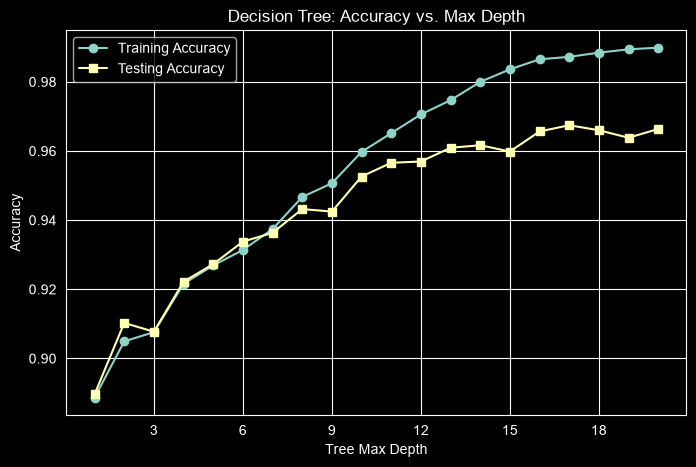

In [7]:
from sklearn.metrics import accuracy_score
from matplotlib.ticker import MaxNLocator

train_scores = []
test_scores = []
depths = range(1, 21)

for d in depths:
    # train the model with training data
    model = DecisionTreeClassifier(max_depth = d, random_state = 69)
    model.fit(features_train, target_train)
    
    # Evaluate on training data
    train_pred = model.predict(features_train)
    train_scores.append(accuracy_score(target_train, train_pred))

    # Evaluate on testing data
    test_pred = model.predict(features_test)
    test_scores.append(accuracy_score(target_test, test_pred))

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', marker='s')
plt.xlabel('Tree Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs. Max Depth')
plt.legend()
plt.grid(True)

# Force the x-axis to use only integers
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [8]:
# Find the index of the highest score in the list
best_index = test_scores.index(max(test_scores))

# use index to grab the depth
best_depth = depths[best_index]
best_readable_depth = depths[2]

# Train the model using
pruned_model = DecisionTreeClassifier(max_depth = best_readable_depth)
pruned_model.fit(features_train, target_train)
predictions = pruned_model.predict(features_test)

# Calculate evaluation metrics
precision = precision_score(target_test, predictions)
recall = recall_score(target_test, predictions)

print(f"Best max_depth: {best_depth}")
print(f"Accuracy: {test_scores[best_index]:.5f}")

print("\nHuman readable depth:")
print(f"Best readable max_depth: {depths[2]}")
print(f"Accuracy: {test_scores[2]:.5f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Best max_depth: 17
Accuracy: 0.96744

Human readable depth:
Best readable max_depth: 3
Accuracy: 0.90774
Precision: 0.8707
Recall: 0.9799


Even though best accuracy can be achieved with higher depths, it is not human readable. 
With depths <5 we can reach accuracy of >90%. max_depth 3 was chosen to reach over 91% accuracy

### 4.3 Pruning

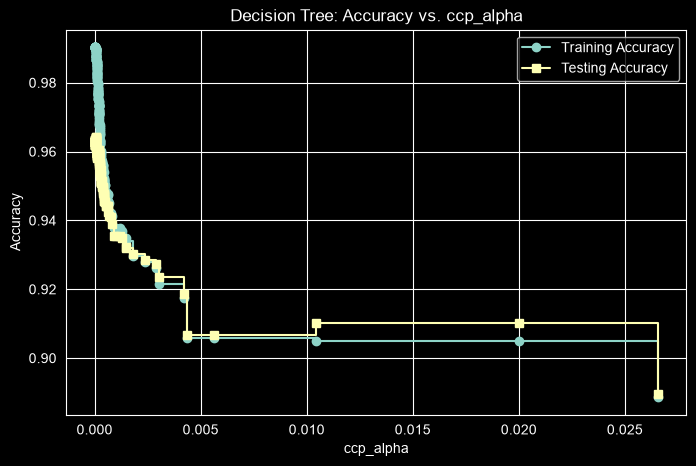

In [9]:
# Grow a full, unconstrained tree to find the pruning path
full_tree = DecisionTreeClassifier(random_state=69)
path = full_tree.cost_complexity_pruning_path(features_train, target_train)
ccp_alphas = path.ccp_alphas

# Test all possible alpha values
train_scores_prune = []
test_scores_prune = []

# (excluding the maximum to avoid a 1-node tree)
valid_alphas = ccp_alphas[:-1]
# Explude high alpha values for easier visuals
valid_alphas = list(filter(lambda x: x <= 0.1, ccp_alphas[:-1]))

for alpha in valid_alphas:
    model = DecisionTreeClassifier(random_state=69, ccp_alpha=alpha)
    model.fit(features_train, target_train)
    
    # Evaluate on training data
    train_pred = model.predict(features_train)
    train_scores_prune.append(accuracy_score(target_train, train_pred))
    
    # Evaluate on testing data
    test_pred = model.predict(features_test)
    test_scores_prune.append(accuracy_score(target_test, test_pred))

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(valid_alphas, train_scores_prune, label='Training Accuracy', marker='o', drawstyle="steps-post")
plt.plot(valid_alphas, test_scores_prune, label='Testing Accuracy', marker='s', drawstyle="steps-post")
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs. ccp_alpha')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# Find the best alpha
best_index = test_scores_prune.index(max(test_scores_prune))
best_alpha = valid_alphas[best_index]

# Magic number based on graph above
target_alpha = 0.011

# Find the closest actual alpha
best_readable_alpha = min(valid_alphas, key=lambda x: abs(x - target_alpha))

# Get the index of that alpha
closest_index = valid_alphas.index(best_readable_alpha)

# Retrieve the corresponding accuracy
readable_accuracy = test_scores_prune[closest_index]

# Train the model using
pruned_model = DecisionTreeClassifier(random_state=69, ccp_alpha=best_readable_alpha)
pruned_model.fit(features_train, target_train)
predictions = pruned_model.predict(features_test)

# Calculate evaluation metrics
precision = precision_score(target_test, predictions)
recall = recall_score(target_test, predictions)

print(f"Best ccp_alpha: {best_alpha:.5f}")
print(f"Accuracy: {max(test_scores_prune):.5f}")

print("\nHuman readable alpha:")
print(f"Best readable ccp_alpha: {best_readable_alpha:.5f}")
print(f"Accuracy for readable tree: {readable_accuracy:.5f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Best ccp_alpha: 0.00007
Accuracy: 0.96418

Human readable alpha:
Best readable ccp_alpha: 0.01044
Accuracy for readable tree: 0.91027
Precision: 0.9222
Recall: 0.9162


### 4.4 Random Forest

####  4.4.1 Creating a Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model_rfc = RandomForestClassifier(n_estimators=100, bootstrap=True, max_samples=0.7, max_features=0.75, random_state=69, max_depth=3)
model_rfc.fit(features_train, target_train)
cv_scores = cross_val_score(model_rfc, features_train, target_train, cv=10)

print(f'Fold-specific accuracies: {cv_scores}')
print(f'\nOverall accuracy (avg. of folds): {cv_scores.mean():.4f}')

predict = model_rfc.predict(features_test)

# Calculate final evaluation metrics
accuracy = accuracy_score(target_test, predict)
precision = precision_score(target_test, predict)
recall = recall_score(target_test, predict)
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Fold-specific accuracies: [0.91927711 0.93606755 0.89626055 0.91556092 0.90108565 0.91556092
 0.90591074 0.92882992 0.90832328 0.93486128]

Overall accuracy (avg. of folds): 0.9162
Accuracy: 0.9200
Precision: 0.9235
Recall: 0.9337


[5.83917678e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.21057342e-02 7.39272996e-03 7.04074228e-01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.44448899e-04 2.23190145e-01 1.72826057e-02 4.68981852e-05
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.51462192e-02 0.00000000e+00 3.61278688e-05
 4.22470930e-04 0.00000000e+00]


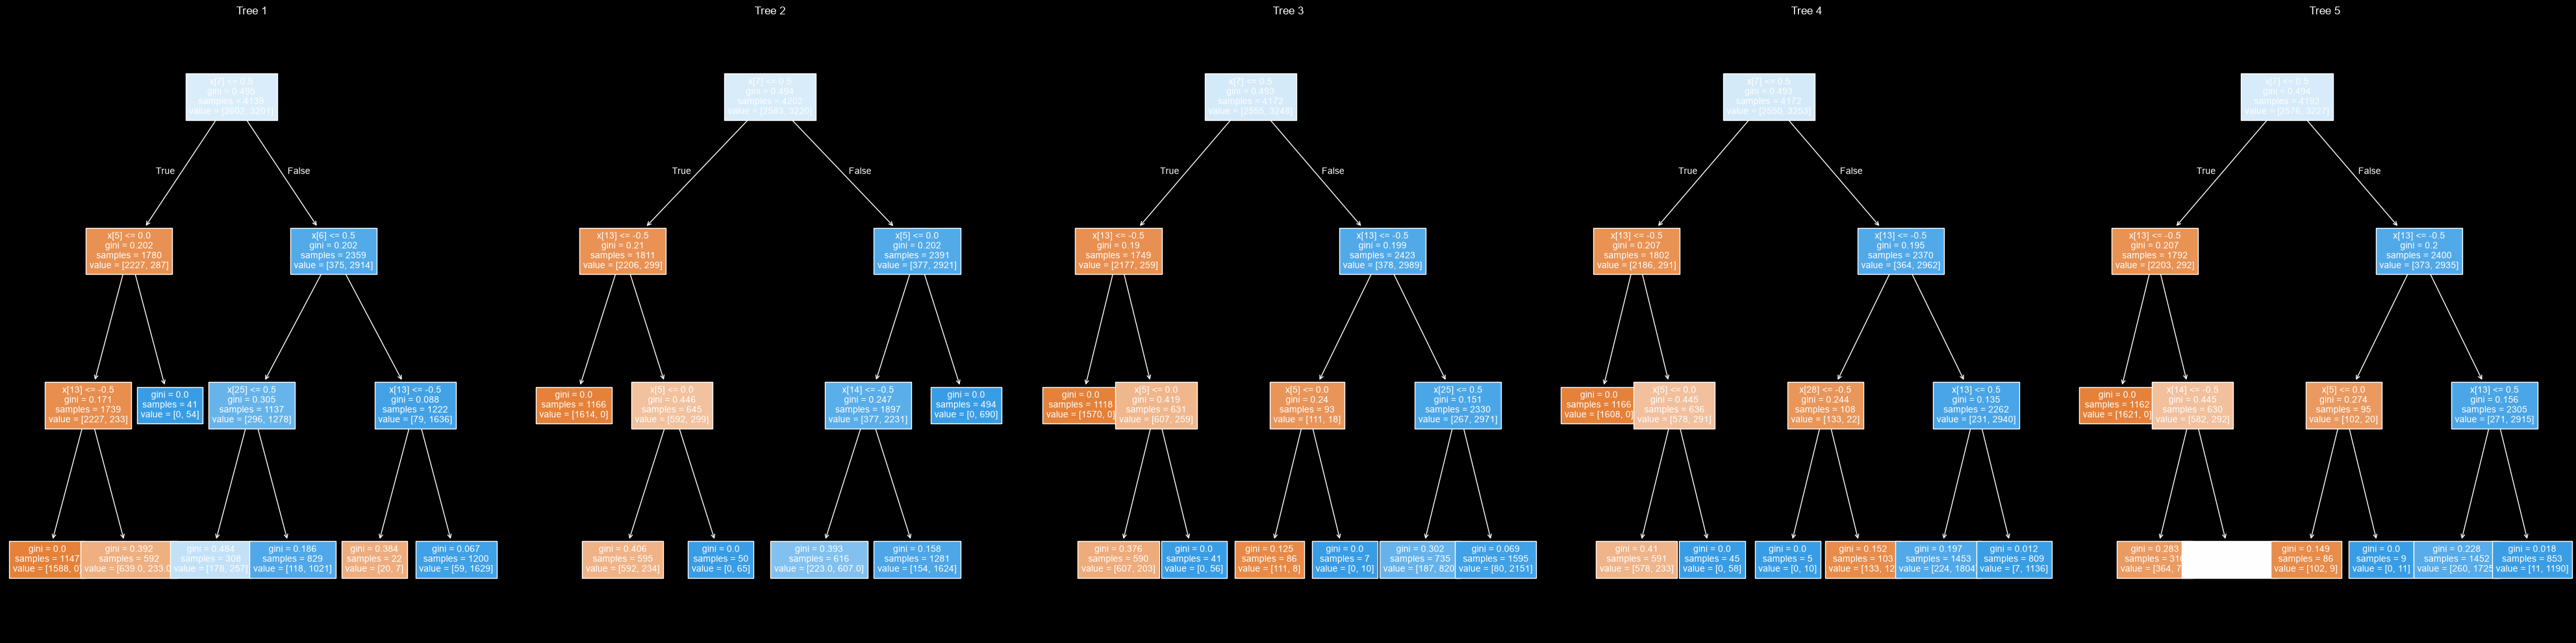

In [12]:
print(model_rfc.feature_importances_)

# Peek a few trees
plt.figure(figsize=(40, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plot_tree(model_rfc.estimators_[i], filled=True, fontsize = 10)
    plt.title(f'Tree {i + 1}')
plt.tight_layout()
plt.show()

#### 4.4.2 Optimizing Forest Hyperparameters
Effects of different hyperparameters can be tested with a brute force approach by creating many combinations of parameters and ranking their performance.

In [13]:
import itertools
from sklearn.model_selection import ParameterGrid

# define ranges and options for hyperparameters
hyperparameter_ranges = {
    "n_estimators" : [10, 50, 100],
    "criterion": ["gini", "entropy"],
    "max_depth" : [1,5,10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 5, 10],
    "max_features" : ["sqrt", "log2", None],
    "bootstrap" : [True, False]
}

# parameters used in previous chapter n_estimators=100, bootstrap=True, max_samples=0.7, max_features=0.75, random_state=69, max_depth=3

# parameter grid has combinations of hyperparameters
parameter_combinations_list : list = list(ParameterGrid(hyperparameter_ranges) )

# print number of combinations
print("Number of hyperparameter combinations created: ", len(parameter_combinations_list))
print("Example parameter combination: ", parameter_combinations_list[0])


Number of hyperparameter combinations created:  1296
Example parameter combination:  {'bootstrap': True, 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}


In [26]:
# multithread section
from joblib import Parallel, delayed
from sklearn.model_selection import cross_val_score

# function to run in a thread
def test_forests(combination : dict, features_train, target_train, features_test, target_test) -> dict:

    # make a forest with the hyperparameter combination.
    forest = RandomForestClassifier(**combination, random_state=69, n_jobs=1)
    forest.fit(features_train, target_train)

    # use forest for prediction
    prediction = forest.predict(features_test)

    # Calculate final evaluation metrics
    accuracy = accuracy_score(target_test, prediction)
    precision = precision_score(target_test, prediction)
    recall = recall_score(target_test, prediction)

    # return combination and results into result list as a tuple
    return { "combination" : combination, "accuracy" : accuracy, "precision" : precision, "recall" : recall }

# test performance of all combinations. Unlimited multiprocessing. Copies of data to reduce global variables
combination_results : list = Parallel(n_jobs=-1, backend="loky", batch_size="auto", return_as="list")( delayed(test_forests)(combination, features_train.copy(), target_train.copy(), features_test.copy(), target_test.copy()) for combination in parameter_combinations_list  )

# number of combinations processed should be same as created
assert len(combination_results) == len(parameter_combinations_list)
print("Number of tested combinations: ", len(combination_results) )

Number of tested combinations:  1296


In [16]:
# sort results by best accuracy, precision and recall print results
def sort_by_accuracy(r):
    return r["accuracy"]
def sort_by_precision(r):
    return r["precision"]
def sort_by_recall(r):
    return r["recall"]

combination_results.sort(key=sort_by_accuracy, reverse=True)
best_accuracy_forest = combination_results[0]
print(f"Sorted by best accuracy:\n Score: {best_accuracy_forest["cv_score"]} accuracy: {best_accuracy_forest["accuracy"]:.4f} precision: {best_accuracy_forest["precision"]:.4f} recall: {best_accuracy_forest["recall"]:.4f} with: {best_accuracy_forest["combination"]} ")

combination_results.sort(key=sort_by_precision, reverse=True)
best_precision_forest = combination_results[0]
print(f"Sorted by best precision:\nScore: {best_precision_forest["cv_score"]} accuracy: {best_precision_forest["accuracy"]:.4f} precision: {best_precision_forest["precision"]:.4f} recall: {best_precision_forest["recall"]:.4f} with: {best_precision_forest["combination"]} ")

combination_results.sort(key=sort_by_recall, reverse=True)
best_recall_forest = combination_results[0]
print(f"Sorted by best recall:\nScore: {best_recall_forest["cv_score"]} accuracy: {best_recall_forest["accuracy"]:.4f} precision: {best_recall_forest["precision"]:.4f} recall: {best_recall_forest["recall"]:.4f} with: {best_recall_forest["combination"]} ")

In [1]:
# sort forests by cross validation score TODO: no cross validation score...
'''

def sort_by_cv_score(r):
    return r["cv_score"]

combination_results.sort(key=sort_by_cv_score, reverse=True)
best_cv_forest = combination_results[0]
print(f"Sorted by best score: {best_cv_forest["cv_score"]} {best_cv_forest["accuracy"]:.4f} precision: {best_cv_forest["precision"]:.4f} recall: {best_cv_forest["recall"]:.4f} with: {best_cv_forest["combination"]} ")

'''

'\n\ndef sort_by_cv_score(r):\n    return r["cv_score"]\n\ncombination_results.sort(key=sort_by_cv_score, reverse=True)\nbest_cv_forest = combination_results[0]\nprint(f"Sorted by best score: {best_cv_forest["cv_score"]} {best_cv_forest["accuracy"]:.4f} precision: {best_cv_forest["precision"]:.4f} recall: {best_cv_forest["recall"]:.4f} with: {best_cv_forest["combination"]} ")\n\n'

#### On decision trees:
- Pruned Decision tree provides smaller tree depth and better results.

#### On Random Forests:
- Optimizing a forest is very computationally intensive.

## 5 Evaluation

Best ccp_alpha: 0.00007
Accuracy: 0.9103
Precision: 0.9222
Recall: 0.9162


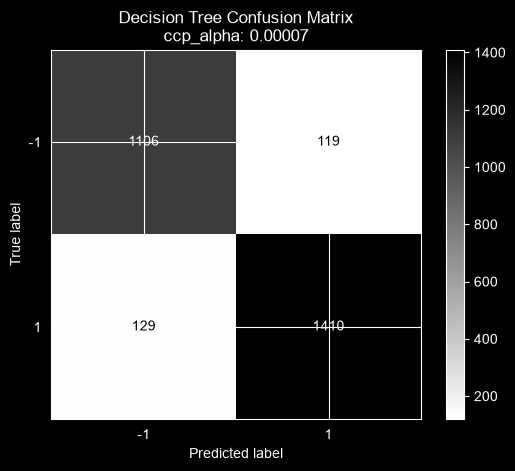

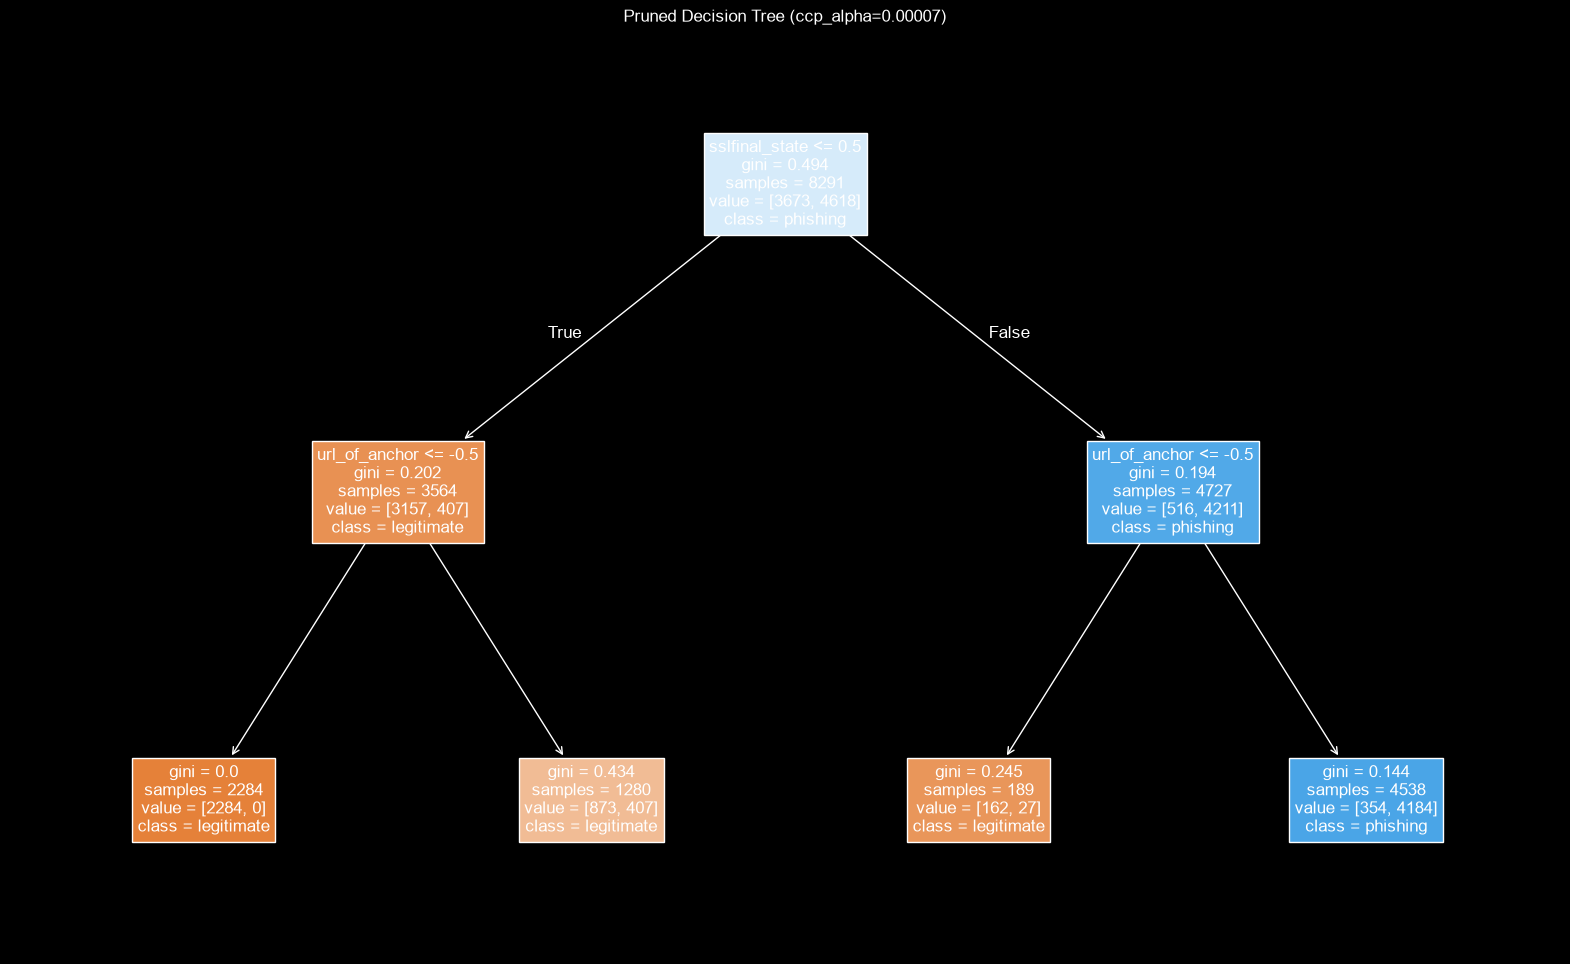

In [17]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train the best model using best_alpha
best_pruned_model = DecisionTreeClassifier(random_state=69, ccp_alpha=best_readable_alpha)

# Fit the pruned model to the training data
best_pruned_model.fit(features_train, target_train)

# Generate final predictions on the test set
final_predictions = best_pruned_model.predict(features_test)

# Calculate final evaluation metrics
accuracy = accuracy_score(target_test, final_predictions)
precision = precision_score(target_test, final_predictions)
recall = recall_score(target_test, final_predictions)

print(f"Best ccp_alpha: {best_alpha:.5f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Generate and display the confusion matrix
cm_final = confusion_matrix(
    target_test,
    final_predictions,
    labels=best_pruned_model.classes_
)

display_final = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=best_pruned_model.classes_
)

display_final.plot(cmap=plt.cm.binary)
plt.title(f"Decision Tree Confusion Matrix\nccp_alpha: {best_alpha:.5f}")
plt.show()

# Visualize the final pruned tree
fig = plt.figure(figsize=(20, 12))
plot_tree(
    best_pruned_model, 
    feature_names=features_test.keys(), 
    class_names=['legitimate', 'phishing'],
    filled=True,
    fontsize=12)

plt.title(f"Pruned Decision Tree (ccp_alpha={best_alpha:.5f})")
plt.show()


## Instruction

### Evaluate the SSL Certificate (sslfinal_state)
Check the sslfinal_state feature.

### Case A: sslfinal_state is -1
- If url_of_anchor is -1 (Tree condition: <= -0.5):
    - Classification: Phishing
    - Confidence: High certainty.
- If url_of_anchor is 0 or 1 (Tree condition: > -0.5):
    - Classification: Phishing
    - Confidence: Moderate certainty.

### Case B: sslfinal_state is 1
- If url_of_anchor is -1 (Tree condition: <= -0.5):
    - Classification: Phishing
    - Confidence: Moderate certainty.
- If url_of_anchor is 0 or 1 (Tree condition: > -0.5):
    - Classification: Legitimate
    - Confidence: High certainty.